sample: 0


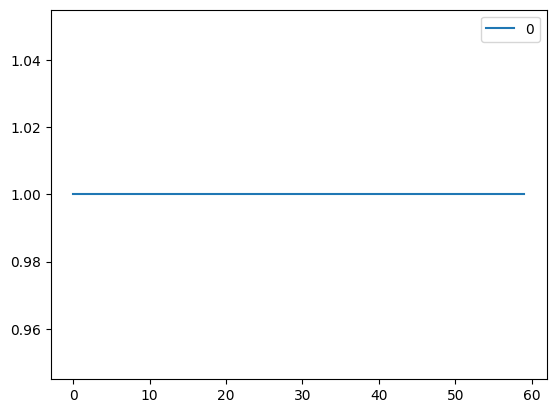

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *


psi=tensor(fock(2,0),fock(2,1),fock(2,0),fock(2,1))
x=Qobj()
f_0_dag=fcreate(4,0)
f_0=f_0_dag.dag()
f_1_dag=fcreate(4,1)
f_1=f_1_dag.dag()
f_2_dag=fcreate(4,2)
f_2=f_2_dag.dag()
f_3_dag=fcreate(4,3)
f_3=f_3_dag.dag()
braid_01=(1j*(np.pi/2)*(f_0_dag*f_1+f_1_dag*f_0)).expm()
braid_12=(1j*(np.pi/2)*(f_1_dag*f_2+f_2_dag*f_1)).expm()
braid_23 = (1j *(np.pi/2)* (f_2_dag * f_3 + f_3_dag * f_2)).expm()
temp=Qobj(np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,-1]]),dims=[[2,2],[2,2]])
fswap_01=tensor(temp,identity(2),identity(2))
fswap_12 = tensor(identity(2),temp,identity(2))
fswap_23 = tensor(identity(2),identity(2),temp)
n_0=f_0_dag*f_0
n_1=f_1_dag*f_1
n_2=f_2_dag*f_2
n_3=f_3_dag*f_3
expect_0_list = []
expect_1_list = []
expect_2_list = []
expect_3_list = []
sample_number=1
for sample in range(sample_number):
    print('sample:', sample)
    expect_0=[]
    expect_1=[]
    expect_2=[]
    expect_3=[]
    psi = tensor(fock(2, 0), fock(2, 1), fock(2, 0), fock(2, 1))
    for cycle in range(20):
        psi = braid_01 * psi
        psi = braid_12 * psi
        psi = braid_23 * psi
        P_list = []
        I=tensor(identity(2),identity(2),identity(2),identity(2))
        project_0_0=0
        project_0_1=0
        for eig in [temp*temp.dag() for temp in n_0.eigenstates()[1][0:8]]:
            project_0_0=project_0_0+eig
        for eig in [temp * temp.dag() for temp in n_0.eigenstates()[1][8:]]:
            project_0_1 = project_0_1 + eig

        project_1_0=0
        project_1_1=0
        for eig in [temp*temp.dag() for temp in n_1.eigenstates()[1][0:8]]:
            project_1_0=project_1_0+eig
        for eig in [temp * temp.dag() for temp in n_1.eigenstates()[1][8:]]:
            project_1_1 = project_1_1 + eig


        project_2_0 = 0
        project_2_1 = 0
        for eig in [temp*temp.dag() for temp in n_2.eigenstates()[1][0:8]]:
            project_2_0=project_2_0+eig
        for eig in [temp * temp.dag() for temp in n_2.eigenstates()[1][8:]]:
            project_2_1 = project_2_1 + eig


        if np.random.rand()<abs(psi.dag()*n_0*psi):
            psi=project_0_1*psi
            psi=psi/psi.norm()
            expect_0.append(expect(n_0,psi))
            expect_1.append(expect(n_1,psi))
            expect_2.append(expect(n_2, psi))
            expect_3.append(expect(n_3, psi))
        else:
            psi=project_0_0*psi
            psi=psi/psi.norm()
            expect_0.append(expect(n_0,psi))
            expect_1.append(expect(n_1,psi))
            expect_2.append(expect(n_2, psi))
            expect_3.append(expect(n_3, psi))
            psi=fswap_01*psi

        if np.random.rand()<abs(psi.dag()*n_2*psi):
            psi=project_2_1*psi
            psi=psi/psi.norm()
            expect_0.append(expect(n_0,psi))
            expect_1.append(expect(n_1,psi))
            expect_2.append(expect(n_2, psi))
            expect_3.append(expect(n_3, psi))
        else:
            psi=project_2_0*psi
            psi=psi/psi.norm()
            expect_0.append(expect(n_0,psi))
            expect_1.append(expect(n_1,psi))
            expect_2.append(expect(n_2, psi))
            expect_3.append(expect(n_3, psi))
            psi=fswap_23*psi

        if np.random.rand()<abs(psi.dag()*n_1*psi):
            psi=project_1_1*psi
            psi=psi/psi.norm()
            expect_0.append(expect(n_0,psi))
            expect_1.append(expect(n_1,psi))
            expect_2.append(expect(n_2, psi))
            expect_3.append(expect(n_3, psi))
        else:
            psi=project_1_0*psi
            psi=psi/psi.norm()
            expect_0.append(expect(n_0,psi))
            expect_1.append(expect(n_1,psi))
            expect_2.append(expect(n_2, psi))
            expect_3.append(expect(n_3, psi))
            psi=fswap_12*psi

    if sample==0:
        expect_0_list = np.array(expect_0)
        expect_1_list = np.array(expect_1)
        expect_2_list = np.array(expect_2)
        expect_3_list = np.array(expect_3)
    else:
        expect_0_list=np.array(expect_0)+expect_0_list
        expect_1_list=np.array(expect_1)+expect_1_list
        expect_2_list=np.array(expect_2)+expect_2_list
        expect_3_list=np.array(expect_3)+expect_3_list

plt.plot(range(len(expect_0_list)),expect_0_list/sample_number)
# plt.plot(range(len(expect_1_list)),expect_1_list/sample_number)
# plt.plot(range(len(expect_2_list)),expect_2_list/sample_number)
# plt.plot(range(len(expect_3_list)),expect_3_list/sample_number)
plt.legend(['0','1','2','3'])
plt.show()


In [21]:
import numpy as np
from qutip import *


f_0_dag=fcreate(2,0)
f_0=f_0_dag.dag()
f_1_dag=fcreate(2,1)
f_1=f_1_dag.dag()

braid=(1j*(np.pi/2)*(f_0_dag*f_1+f_1_dag*f_0)).expm()
fswap=Qobj(np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,-1]]),dims=[[2,2],[2,2]])

gamma_0=f_0_dag+f_0
gamma_0_prem=1j*(f_0-f_0_dag)
gamma_1=f_1_dag+f_1
gamma_1_prem=1j*(f_1-f_1_dag)
stabilizers=[tensor(identity(2),identity(2)),gamma_0,gamma_0_prem,gamma_1,gamma_1_prem,gamma_0*gamma_0_prem,gamma_1*gamma_1_prem,gamma_0*gamma_1,gamma_0_prem*gamma_1_prem,gamma_0*gamma_1_prem,gamma_0_prem*gamma_1,gamma_0*gamma_0_prem*gamma_1,gamma_0*gamma_0_prem*gamma_1_prem,gamma_0*gamma_1*gamma_1_prem,gamma_0_prem*gamma_1*gamma_1_prem,gamma_0*gamma_0_prem*gamma_1*gamma_1_prem]
name=[[[0,0],[0,0]],
      [[1,0],[0,0]],
      [[0,1],[0,0]],
      [[0,0],[1,0]],
      [[0,0],[0,1]],
      [[1,1],[0,0]],
      [[0,0],[1,1]],
      [[1,0],[1,0]],
      [[0,1],[0,1]],
      [[1,0],[0,1]],
      [[0,1],[1,0]],
      [[1,1],[1,0]],
      [[1,1],[0,1]],
      [[1,0],[1,1]],
      [[0,1],[1,1]],
      [[1,1],[1,1]]]
for temp in [gamma_0,gamma_0_prem,gamma_1,gamma_1_prem]:
    for i in range(len(stabilizers)):
        if (fswap*temp*fswap.dag()-stabilizers[i]).norm()<0.0001:

            print('+'+str(name[i]))
            break
        if (fswap*temp*fswap.dag()+stabilizers[i]).norm()<0.0001:
            print('-'+str(name[i]))
            break



+[[0, 0], [1, 0]]
+[[0, 0], [0, 1]]
+[[1, 0], [0, 0]]
+[[0, 1], [0, 0]]
